# CHƯƠNG 6 - ĐÁNH GIÁ MÔ HÌNH

## 6.1 Kết quả trên từng mô hình

### Khai báo thư viện

In [3]:
from __future__ import annotations

from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split


### Đọc dữ liệu

In [4]:
plt.rcParams["figure.figsize"] = (8, 6)

RANDOM_STATE = 42
TEST_SIZE = 0.2
VALID_SIZE = 0.2

BASE_DIR = Path("..")
DATA_PATH = BASE_DIR / "pima-indians-diabetes.csv"
OUT_DIR = BASE_DIR / "outputs"
TABLE_DIR = OUT_DIR / "tables"
MODEL_DIR = OUT_DIR / "models"

TARGET_COL = "Outcome"
ALL_COLS = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome",
]
ZERO_AS_MISSING_COLS = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
]

In [5]:
def load_data(path: Path) -> pd.DataFrame:
    return pd.read_csv(path, header=None, names=ALL_COLS)

def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for col in ZERO_AS_MISSING_COLS:
        df.loc[df[col] == 0, col] = np.nan
    return df

### Chia lại dữ liệu

In [6]:
def split_data(df: pd.DataFrame):
    X = df.drop(columns=[TARGET_COL])
    y = df[TARGET_COL].astype(int)

    X_trainval, X_test, y_trainval, y_test = train_test_split(
        X, y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y,
    )

    valid_ratio_from_trainval = VALID_SIZE / (1.0 - TEST_SIZE)
    X_train, X_valid, y_train, y_valid = train_test_split(
        X_trainval, y_trainval,
        test_size=valid_ratio_from_trainval,
        random_state=RANDOM_STATE,
        stratify=y_trainval,
    )

    return X_train, X_valid, X_test, y_train, y_valid, y_test

### Tính các độ đo đánh giá

In [7]:
def eval_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "auc": roc_auc_score(y_test, y_proba),
        "y_pred": y_pred,
        "y_proba": y_proba,
    }

df = clean_data(load_data(DATA_PATH))
X_train, X_valid, X_test, y_train, y_valid, y_test = split_data(df)

### Kết quả

In [8]:
versions = ["raw", "minmax", "standard"]
models = ["LogisticRegression", "KNN", "DecisionTree", "RandomForest"]

rows = []
for version in versions:
    for model_name in models:
        model_path = MODEL_DIR / f"{version}_{model_name}.joblib"
        model = joblib.load(model_path)

        m = eval_model(model, X_test, y_test)
        rows.append({
            "version": version,
            "model": model_name,
            "accuracy": m["accuracy"],
            "precision": m["precision"],
            "recall": m["recall"],
            "f1": m["f1"],
            "auc": m["auc"],
        })

        print(f"\n[{version}] {model_name}")
        print(f"accuracy = {m['accuracy']:.4f}")
        print(f"precision = {m['precision']:.4f}")
        print(f"recall = {m['recall']:.4f}")
        print(f"f1 = {m['f1']:.4f}")
        print(f"auc = {m['auc']:.4f}")


[raw] LogisticRegression
accuracy = 0.7078
precision = 0.6047
recall = 0.4815
f1 = 0.5361
auc = 0.8170

[raw] KNN
accuracy = 0.7013
precision = 0.5870
recall = 0.5000
f1 = 0.5400
auc = 0.7764

[raw] DecisionTree
accuracy = 0.7078
precision = 0.6364
recall = 0.3889
f1 = 0.4828
auc = 0.7619

[raw] RandomForest
accuracy = 0.7143
precision = 0.6087
recall = 0.5185
f1 = 0.5600
auc = 0.8198

[minmax] LogisticRegression
accuracy = 0.7143
precision = 0.6136
recall = 0.5000
f1 = 0.5510
auc = 0.8169

[minmax] KNN
accuracy = 0.7273
precision = 0.6429
recall = 0.5000
f1 = 0.5625
auc = 0.7931

[minmax] DecisionTree
accuracy = 0.7078
precision = 0.6364
recall = 0.3889
f1 = 0.4828
auc = 0.7619

[minmax] RandomForest
accuracy = 0.7208
precision = 0.6222
recall = 0.5185
f1 = 0.5657
auc = 0.8209

[standard] LogisticRegression
accuracy = 0.7078
precision = 0.6000
recall = 0.5000
f1 = 0.5455
auc = 0.8146

[standard] KNN
accuracy = 0.7403
precision = 0.6591
recall = 0.5370
f1 = 0.5918
auc = 0.8082

[stand

## 6.2 So sánh theo phương pháp chuẩn hóa

In [10]:
results_df = pd.DataFrame(rows).sort_values("auc", ascending=False)
results_df.to_excel(TABLE_DIR / "test_results.xlsx", index=False)
display(results_df)

,version,model,accuracy,precision,recall,f1,auc
7,minmax,RandomForest,0.720779,0.622222,0.518519,0.565657,0.820926
3,raw,RandomForest,0.714286,0.608696,0.518519,0.560000,0.819815
0,raw,LogisticRegression,0.707792,0.604651,0.481481,0.536082,0.817037
4,minmax,LogisticRegression,0.714286,0.613636,0.500000,0.551020,0.816852
8,standard,LogisticRegression,0.707792,0.600000,0.500000,0.545455,0.814630
11,standard,RandomForest,0.746753,0.666667,0.555556,0.606061,0.812037
9,standard,KNN,0.740260,0.659091,0.537037,0.591837,0.808241
5,minmax,KNN,0.727273,0.642857,0.500000,0.562500,0.793056
1,raw,KNN,0.701299,0.586957,0.500000,0.540000,0.776389
2,raw,DecisionTree,0.707792,0.636364,0.388889,0.482759,0.761944


## 6.3 Ma trận nhầm lẫn

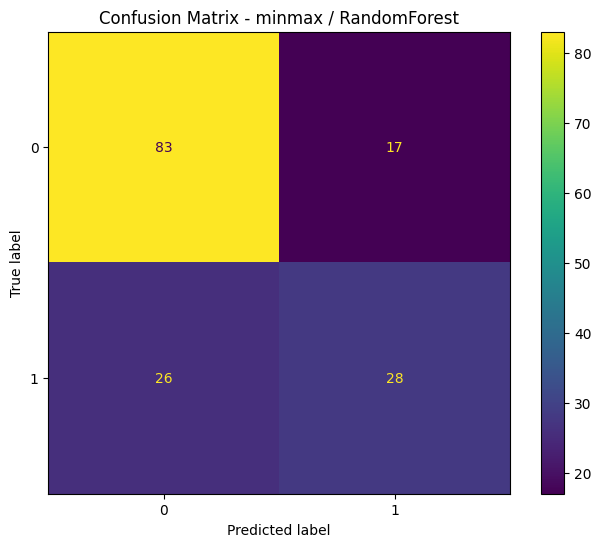

In [13]:
best_row = results_df.iloc[0]
best_model = joblib.load(MODEL_DIR / f"{best_row['version']}_{best_row['model']}.joblib")
best_eval = eval_model(best_model, X_test, y_test)

cm = confusion_matrix(y_test, best_eval["y_pred"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot()
plt.title(f"Confusion Matrix - {best_row['version']} / {best_row['model']}")
plt.show()

## ROC Curve và AUC

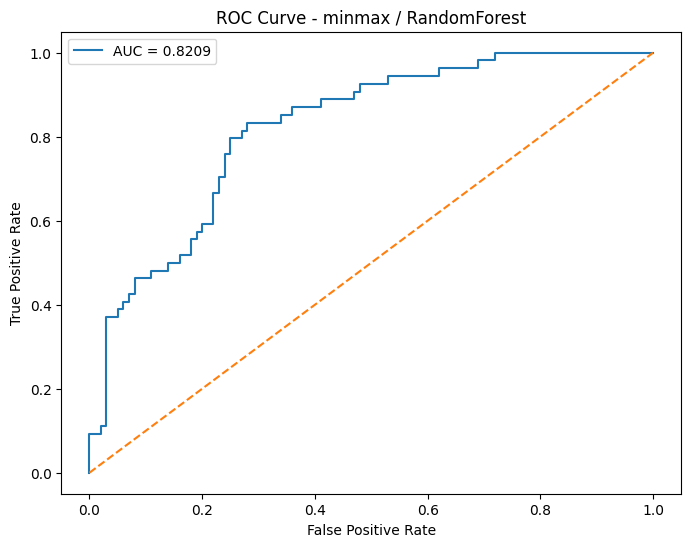

In [14]:
fpr, tpr, _ = roc_curve(y_test, best_eval["y_proba"])
plt.plot(fpr, tpr, label=f"AUC = {best_eval['auc']:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - {best_row['version']} / {best_row['model']}")
plt.legend()
plt.show()


## 6.5 Nhận xét và phân tích kết quả

In [18]:
print("\nKẾT LUẬN CHỌN MÔ HÌNH")
print(f"Phiên bản dữ liệu: {best_row['version']}")
print(f"Mô hình: {best_row['model']}")
print(f"AUC: {best_eval['auc']:.4f}")
print(f"Accuracy: {best_eval['accuracy']:.4f}")

print("\nNhận xét và phân tích: Mô hình RandomForest trên dữ liệu Min-Max đạt kết quả tốt nhất trong các thử nghiệm.")
print("AUC = 0.8209 cho thấy khả năng phân biệt hai lớp khá tốt.")
print("Accuracy = 0.7208, mức chấp nhận được cho bài toán phân lớp tiểu đường.")


KẾT LUẬN CHỌN MÔ HÌNH
Phiên bản dữ liệu: minmax
Mô hình: RandomForest
AUC: 0.8209
Accuracy: 0.7208

Nhận xét và phân tích: Mô hình RandomForest trên dữ liệu Min-Max đạt kết quả tốt nhất trong các thử nghiệm.
AUC = 0.8209 cho thấy khả năng phân biệt hai lớp khá tốt.
Accuracy = 0.7208, mức chấp nhận được cho bài toán phân lớp tiểu đường.


# Kết thúc